## Tugas - Klasifikasi dengan Artificial Neural Network (ANN)

| Nama | NRP |
|------|-----|
| Evina Fitriyani | 5054251013 |

### Deskripsi Tugas
Pada tugas ini, kalian akan membangun model ANN (Multi-Layer Perceptron) Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut: (https://www.kaggle.com/datasets/blastchar/telco-customer-churn)

Tujuan utama dari tugas ini adalah memahami cara kerja ANN secara praktik, khususnya:

1. Perbedaan hasil antar fungsi aktivasi (ReLU, Tanh, Logistic/Sigmoid)
2. Pengaruh ukuran arsitektur (hidden_layer_sizes) dan jumlah iterasi terhadap gejala overfitting

Langkah-langkah yang harus dilakukan antara lain:

1. Persiapan Dataset dan Eksplorasi Awal
- Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
- Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
- Bangun model ANN dengan arsitektur dasar.
- Lakukan eksperimen fungsi aktivasi dan regularisasi arsitektur.
4. Evaluasi Model
- Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
- Bandingkan hasil eksperimen dan berikan kesimpulan.

## 1. Persiapan Dataset dan Eksplorasi Awal

In [2]:
# Import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

sns.set_style("whitegrid")
RANDOM_STATE = 42

In [3]:
# Load dataset
# Download dataset dari Kaggle lalu taruh file CSV-nya satu folder dengan notebook ini
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Jumlah baris dan kolom:", df.shape)
df.head()

Jumlah baris dan kolom: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Informasi dasar dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Statistik deskriptif
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [6]:
# Cek missing value
df.isnull().sum().sort_values(ascending=False)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# Kolom TotalCharges kadang berupa string dengan spasi kosong -> perlu dikonversi ke numerik
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# cek ulang missing value setelah konversi
df.isnull().sum().sort_values(ascending=False)

TotalCharges        11
gender               0
SeniorCitizen        0
Partner              0
customerID           0
Dependents           0
tenure               0
MultipleLines        0
PhoneService         0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
InternetService      0
TechSupport          0
StreamingTV          0
Contract             0
StreamingMovies      0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
Churn                0
dtype: int64

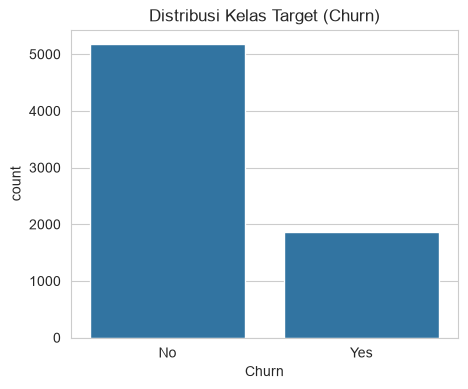

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [8]:
# Distribusi kelas target (Churn)
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x="Churn")
plt.title("Distribusi Kelas Target (Churn)")
plt.show()

print(df["Churn"].value_counts(normalize=True))

Perhatikan proporsi kelas `Yes` vs `No` pada output di atas dataset ini termasuk **imbalanced** (kelas churn `No` jauh lebih banyak dari `Yes`), jadi metrik seperti Precision, Recall, dan F1-Score penting untuk dilihat, bukan hanya Accuracy.

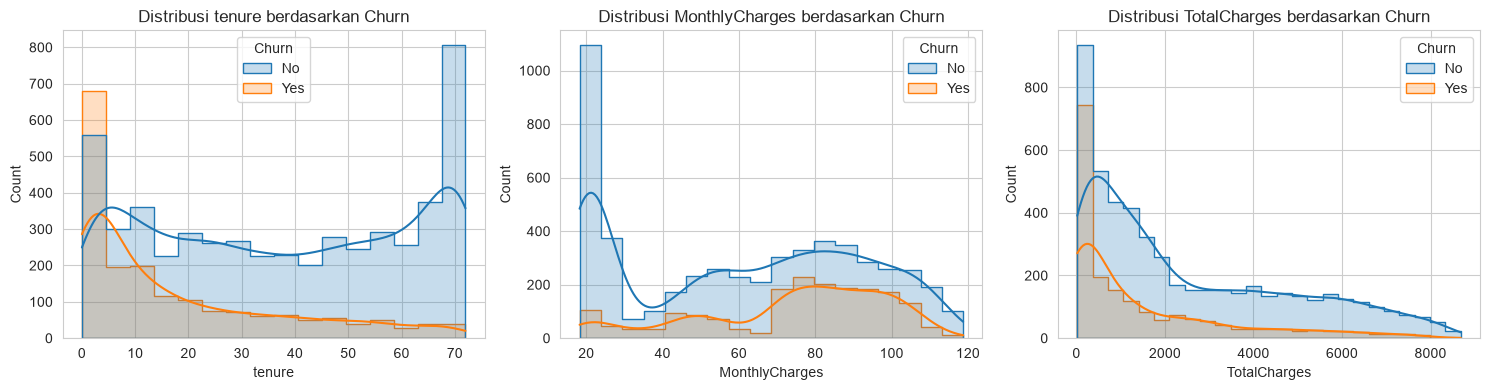

In [9]:
# Distribusi fitur numerik dibedakan berdasarkan kelas target

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", kde=True, ax=ax, element="step")
    ax.set_title(f"Distribusi {col} berdasarkan Churn")
plt.tight_layout()
plt.show()

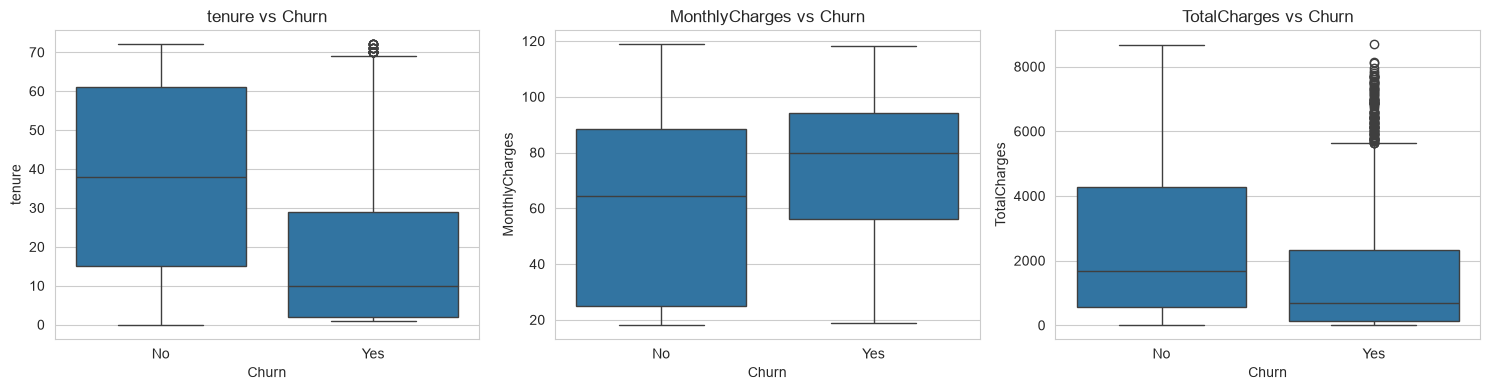

In [10]:
# Boxplot fitur numerik berdasarkan Churn
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df, x="Churn", y=col, ax=ax)
    ax.set_title(f"{col} vs Churn")
plt.tight_layout()
plt.show()

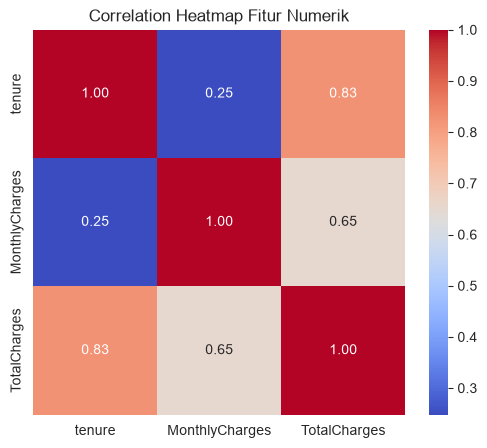

In [11]:
# Correlation heatmap untuk fitur numerik
plt.figure(figsize=(6, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap Fitur Numerik")
plt.show()

**EDA tambahan (opsional, silakan dikembangkan):** cek juga distribusi fitur kategorikal penting seperti `Contract`, `InternetService`, atau `PaymentMethod` terhadap `Churn` menggunakan countplot bertumpuk (`hue="Churn"`), karena fitur-fitur ini biasanya cukup informatif untuk churn prediction.

## 2. Preprocessing

In [12]:
# Kolom customerID tidak informatif untuk model, hapus
df = df.drop(columns=["customerID"])

# Tangani missing value pada TotalCharges
# Strategi: baris dengan TotalCharges kosong biasanya adalah pelanggan baru (tenure = 0),
# jadi lebih aman diisi 0 daripada dihapus atau diisi mean (menghindari asumsi berlebih / bias)
df["TotalCharges"] = df["TotalCharges"].fillna(0)

df.isnull().sum().sum()  # pastikan sudah 0

np.int64(0)

In [13]:
# Encoding target
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

# Pisahkan fitur kategorikal dan numerik
categorical_cols = df.select_dtypes(include="object").columns.tolist()
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numeric_cols.remove("Churn")

print("Fitur kategorikal:", categorical_cols)
print("Fitur numerik:", numeric_cols)

Fitur kategorikal: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Fitur numerik: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


C:\Users\ACER\AppData\Local\Temp\ipykernel_15692\3622382080.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns.tolist()


In [14]:
# One-Hot Encoding untuk fitur kategorikal
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.shape

(7043, 31)

In [15]:
# Pisahkan fitur (X) dan target (y)
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# Bagi data menjadi train set dan test set (80:20), stratify=y agar distribusi kelas proporsional
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5634, 30)
Test shape: (1409, 30)


In [16]:
# Feature scaling (StandardScaler)
# fit_transform hanya pada train set, transform saja pada test set -> menghindari data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Eksperimen Model

### 3.1 ANN dengan Arsitektur Dasar

In [17]:
# Baseline: MLPClassifier dengan satu hidden layer
mlp_baseline = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation="relu",
    max_iter=500,
    random_state=RANDOM_STATE
)
mlp_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = mlp_baseline.predict(X_test_scaled)

baseline_acc = accuracy_score(y_test, y_pred_baseline)
print(f"Akurasi baseline (ReLU, hidden_layer_sizes=(10,)): {baseline_acc:.4f}")

Akurasi baseline (ReLU, hidden_layer_sizes=(10,)): 0.7878


### 3.2 Eksperimen Fungsi Aktivasi

Fungsi aktivasi menentukan bagaimana neuron "mengaktivasikan" keluarannya dan memungkinkan model mempelajari pola non-linear. Bandingkan beberapa pilihan fungsi aktivasi yang tersedia di scikit-learn.

In [19]:
# Bandingkan beberapa fungsi aktivasi: relu, tanh, logistic
activations = ["relu", "tanh", "logistic"]
activation_results = {}
activation_models = {}

for act in activations:
    model = MLPClassifier(
        hidden_layer_sizes=(10,),
        activation=act,
        max_iter=500,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    activation_results[act] = acc
    activation_models[act] = model

activation_df = pd.DataFrame(
    list(activation_results.items()), columns=["Activation", "Test Accuracy"]
).sort_values("Test Accuracy", ascending=False)

activation_df

,Activation,Test Accuracy
1,tanh,0.793471
2,logistic,0.792761
0,relu,0.787793


In [20]:
# Tentukan fungsi aktivasi terbaik untuk digunakan di eksperimen 3.3
best_activation = activation_df.iloc[0]["Activation"]
print("Fungsi aktivasi terbaik:", best_activation)

Fungsi aktivasi terbaik: tanh


### 3.3 Eksperimen Regularisasi: Pengaruh Ukuran Arsitektur terhadap Overfitting

Semakin besar/dalam arsitektur ANN (jumlah neuron dan hidden layer), semakin besar kapasitas model untuk menghafal data training. Pada bagian ini kalian akan mengamati bagaimana perubahan ukuran arsitektur memengaruhi akurasi training dan testing.

In [21]:
# Variasi hidden_layer_sizes, menggunakan activation terbaik dari 3.2
architectures = [(2,), (5,), (10,), (50,), (100, 50)]
architecture_results = []
architecture_models = {}

for arch in architectures:
    model = MLPClassifier(
        hidden_layer_sizes=arch,
        activation=best_activation,
        max_iter=500,
        random_state=RANDOM_STATE
    )
    model.fit(X_train_scaled, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train_scaled))
    test_acc = accuracy_score(y_test, model.predict(X_test_scaled))

    architecture_results.append({
        "Architecture": str(arch),
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc
    })
    architecture_models[str(arch)] = model

architecture_df = pd.DataFrame(architecture_results)
architecture_df

C:\Users\ACER\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


,Architecture,Train Accuracy,Test Accuracy
0,"(2,)",0.805999,0.794890
1,"(5,)",0.810969,0.790632
2,"(10,)",0.824636,0.793471
3,"(50,)",0.895989,0.751597
4,"(100, 50)",0.959176,0.754436


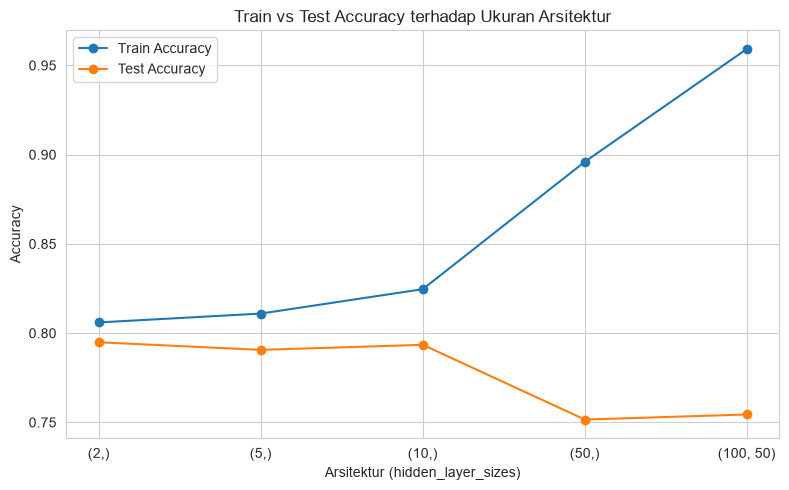

In [22]:
# Plot akurasi training vs testing terhadap ukuran arsitektur
plt.figure(figsize=(8, 5))
x_labels = architecture_df["Architecture"]
plt.plot(x_labels, architecture_df["Train Accuracy"], marker="o", label="Train Accuracy")
plt.plot(x_labels, architecture_df["Test Accuracy"], marker="o", label="Test Accuracy")
plt.xlabel("Arsitektur (hidden_layer_sizes)")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy terhadap Ukuran Arsitektur")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Evaluasi Model

In [23]:
# Pilih model dengan performa terbaik dari eksperimen 3.2 dan 3.3
best_activation_model = activation_models[best_activation]

best_arch_row = architecture_df.loc[architecture_df["Test Accuracy"].idxmax()]
best_arch_key = best_arch_row["Architecture"]
best_arch_model = architecture_models[best_arch_key]

def evaluate_model(model, name):
    y_pred = model.predict(X_test_scaled)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    }

eval_results = [
    evaluate_model(best_activation_model, f"Best Activation ({best_activation})"),
    evaluate_model(best_arch_model, f"Best Architecture ({best_arch_key})"),
]

eval_df = pd.DataFrame(eval_results)
eval_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Best Activation (tanh),0.793471,0.630094,0.537433,0.580087
1,"Best Architecture ((2,))",0.794890,0.632399,0.542781,0.584173


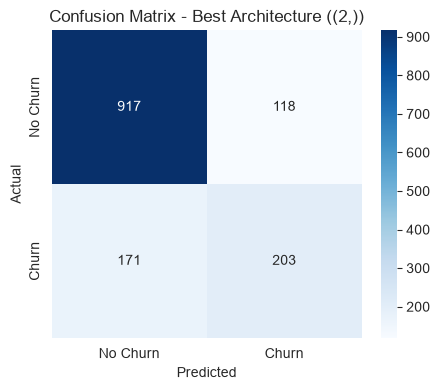

              precision    recall  f1-score   support

    No Churn       0.84      0.89      0.86      1035
       Churn       0.63      0.54      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [24]:
# Confusion Matrix untuk model dengan performa terbaik (pilih dari eval_df yang F1-Score tertinggi)
overall_best_name = eval_df.loc[eval_df["F1-Score"].idxmax(), "Model"]
overall_best_model = best_activation_model if "Activation" in overall_best_name else best_arch_model

y_pred_best = overall_best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {overall_best_name}")
plt.show()

print(classification_report(y_test, y_pred_best, target_names=["No Churn", "Churn"]))

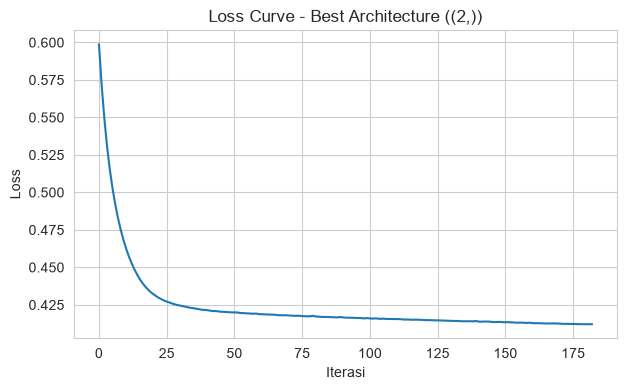

Jumlah iterasi yang dijalankan: 183
Loss akhir: 0.412065644923491


In [25]:
# Loss curve dari model dengan performa terbaik
plt.figure(figsize=(7, 4))
plt.plot(overall_best_model.loss_curve_)
plt.xlabel("Iterasi")
plt.ylabel("Loss")
plt.title(f"Loss Curve - {overall_best_name}")
plt.show()

print("Jumlah iterasi yang dijalankan:", overall_best_model.n_iter_)
print("Loss akhir:", overall_best_model.loss_curve_[-1])

Perhatikan bentuk loss curve di atas: kalau kurva sudah landai/flat menjelang akhir, berarti model sudah **konvergen**. Kalau masih menurun tajam saat `max_iter` tercapai, berarti model **belum konvergen sepenuhnya** dan `max_iter` perlu dinaikkan.

## 5. Analisis

Perbandingan fungsi aktivasi

Hasil eksperimen menunjukkan akurasi test untuk ketiga fungsi aktivasi cukup berdekatan: tanh sebesar 0,7935, logistic sebesar 0,7928, dan ReLU sebesar 0,7878. Selisih antar fungsi aktivasi hanya sekitar 0,5–0,6 poin persentase, sehingga perbedaan ini tidak dapat dikategorikan signifikan secara praktis.

Kondisi ini dapat dijelaskan dari sisi arsitektur yang digunakan. Model baseline hanya memiliki satu hidden layer dengan 10 neuron, sehingga jaringannya tergolong dangkal. Permasalahan yang biasanya membedakan performa antar fungsi aktivasi seperti vanishing gradient pada sigmoid/tanh yang memperlambat proses pembelajaran pada jaringan dalam — belum cukup terasa pada arsitektur sedangkal ini. Ketiga fungsi aktivasi sama-sama mampu memetakan hubungan non-linear pada data dengan kapasitas yang setara, sehingga hasil akhirnya pun relatif seimbang.

Eksperimen ukuran arsitektur

Tabel architecture_df memperlihatkan pola yang jelas terkait overfitting. Pada arsitektur (2,), (5,), dan (10,), train accuracy dan test accuracy masih berada pada rentang yang berdekatan (train 0,806–0,825, test 0,791–0,795). Namun mulai arsitektur (50,), gap antara keduanya melebar signifikan: train accuracy naik menjadi 0,896 sementara test accuracy justru turun menjadi 0,752. Pada arsitektur (100, 50), pola ini semakin nyata train accuracy mencapai 0,959, sedangkan test accuracy tetap berada di kisaran rendah yaitu 0,754.

Ciri overfitting yang terlihat dari grafik adalah train accuracy yang terus meningkat mendekati 1,0 seiring bertambahnya ukuran arsitektur, sementara test accuracy justru stagnan bahkan menurun setelah arsitektur (10,). Ini mengindikasikan bahwa penambahan kapasitas model di atas titik tersebut hanya membuat model semakin menghafal data training, tanpa perbaikan kemampuan generalisasi. Temuan tambahan yang relevan adalah arsitektur paling sederhana, yaitu (2,), justru mencatat test accuracy tertinggi di antara seluruh variasi yang diuji (0,795), yang menunjukkan bahwa permasalahan klasifikasi ini tidak memerlukan kapasitas model yang besar.

Konvergensi berdasarkan loss curve

Loss curve dari model terbaik, yaitu arsitektur (2,) dengan aktivasi tanh, menunjukkan penurunan tajam dari sekitar 0,60 menjadi 0,43 dalam 25 iterasi pertama, kemudian melandai secara bertahap hingga mencapai nilai akhir 0,412 pada iterasi ke-183. Training berhenti pada iterasi tersebut meskipun max_iter ditetapkan sebesar 500, yang berarti proses training dihentikan otomatis karena penurunan loss sudah berada di bawah ambang toleransi, bukan karena keterbatasan jumlah iterasi. Berdasarkan pola ini, model dapat dikatakan sudah konvergen dengan baik.

Apabila pada eksperimen lain ditemukan loss curve yang masih menurun tajam ketika max_iter tercapai, langkah yang perlu diambil adalah menaikkan nilai max_iter agar model memiliki kesempatan menyelesaikan proses optimisasi, serta memeriksa learning_rate_init nilai yang terlalu kecil dapat membuat proses konvergensi berjalan lambat. Pemeriksaan terhadap solver yang digunakan juga perlu dilakukan untuk memastikan kesesuaiannya dengan ukuran dataset.

## 6. Kesimpulan dan Saran

**Kesimpulan**

Perbedaan performa antar fungsi aktivasi pada eksperimen ini tergolong kecil dan tidak signifikan, dengan tanh memberikan hasil sedikit lebih baik dibanding logistic dan ReLU pada arsitektur dangkal yang digunakan. Eksperimen ukuran arsitektur menunjukkan bahwa gejala overfitting mulai muncul pada arsitektur (50,) dan semakin nyata pada (100, 50), sementara arsitektur paling sederhana, yaitu (2,), justru memberikan generalisasi terbaik dengan test accuracy 0,795. Model terbaik pada penelitian ini, yaitu arsitektur (2,) dengan aktivasi tanh, telah mencapai konvergensi sebelum batas max_iter terpenuhi. Meski demikian, performa model pada kelas churn masih tergolong moderat, dengan recall sebesar 0,54 dan F1-score sebesar 0,584, yang mengindikasikan model masih cukup sering gagal mendeteksi pelanggan yang benar-benar melakukan churn.

**Saran**

Untuk pengembangan lebih lanjut, penanganan ketidakseimbangan kelas perlu dipertimbangkan, misalnya melalui parameter class_weight atau teknik oversampling seperti SMOTE, guna meningkatkan recall pada kelas churn. Hyperparameter tuning menggunakan GridSearchCV juga dapat diterapkan untuk mengoptimalkan kombinasi hidden_layer_sizes, alpha, dan learning_rate_init secara sistematis. Selain itu, perbandingan dengan algoritma lain seperti Random Forest atau SVM dapat memberikan gambaran apakah performa ANN pada dataset ini sudah kompetitif atau masih dapat ditingkatkan.